# MNLI Plotting — Chapter 4

Reads `results/mnli_all.pkl` (structure: `D[alpha][strategy][seed]`)
and produces all publication-quality figures and LaTeX tables for Chapter 4.

**Figure map**
| Fig | File | Purpose |
|-----|------|---------|
| 1 | g1_acc_round | Accuracy vs Round (α=2) |
| 2 | g1_acc_wallclock | Accuracy vs Wall-Clock (α=2) |
| 3 | g1_jfi_round | JFI vs Round (α=2) |
| 4 | g1_exploration | Exploration Ratio (α=2) |
| 5 | g1_straggler | Straggler Summary bars (α=2) |
| 6 | g2_acc_round | 3-panel Accuracy vs Round (all α) |
| 7 | g2_jfi_round | 3-panel JFI vs Round (all α) |
| 8 | g2_cross_alpha | Cross-α grouped bars |
| 9 | rq2_loss_cv | Loss-CV vs Round (RQ2: utility signal) |
| 10 | rq2_oort_t | Oort preferred-T trajectory (RQ2: mechanism) |

**Table map**
| Table | File | Content |
|-------|------|---------|
| 1 | tab_efficiency | RTA / TTA / MRD / BestAcc (α=2) |
| 2 | tab_fairness | JFI / ΔJFI / NeverSel / StragOH (α=2) |
| 3 | tab_cross_alpha | Key metrics × strategy × α |

In [111]:
import pickle
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

os.makedirs("results/figures", exist_ok=True)

with open("results/mnli_all.pkl", "rb") as f:
    D = pickle.load(f)

print("Loaded keys:", {str(a): list(D[a].keys()) for a in D})

Loaded keys: {'0.5': ['random', 'fedcs', 'tifl', 'oort'], '2.0': ['random', 'fedcs', 'tifl', 'oort'], 'iid': ['random', 'fedcs', 'tifl', 'oort']}


## Style & shared helpers

In [112]:
plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "legend.fontsize":   10,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
})

STRATEGIES  = ["random", "fedcs", "tifl", "oort"]
ALPHAS      = [0.5, 2.0, "iid"]
ALPHA_SEEDS = {0.5: [42, 123, 456], 2.0: [42, 123, 456], "iid": [42]}
ALPHA_LABELS = {0.5: r"$\alpha{=}0.5$", 2.0: r"$\alpha{=}2$", "iid": "IID"}
R_MAX       = 100
TARGET_ACC  = 0.80
N_CLIENTS   = 300
K = 30  # clients selected per round

COLORS = {
    "random": "#555555",
    "fedcs":  "#ed2d2d",
    "tifl":   "#3acd3a",
    "oort":   "#2794e1",
}
LINES = {
    "random": "-",
    "fedcs":  "-.",
    "tifl":   "--",
    "oort":   "-.",
}
LABELS = {
    "random": "Random",
    "fedcs":  "FedCS",
    "tifl":   "TiFL",
    "oort":   "Oort",
}

# Alpha condition bar colors for cross-alpha plots
ALPHA_COLORS = {0.5: "#ed2d2d", 2.0: "#2794e1", "iid": "#3acd3a"}

def _get_seeds(alpha, strategy):
    return [
        s for s in ALPHA_SEEDS[alpha]
        if D[alpha][strategy].get(s) is not None
    ]


def get_series(alpha, strategy, key, n_rounds=R_MAX):
    """Stack a per-round series across seeds → (n_seeds, n_rounds) array.
    Single-seed conditions (IID) return a (1, n_rounds) array.
    """
    rows = []
    for seed in _get_seeds(alpha, strategy):
        m = D[alpha][strategy][seed]
        s = m[key]
        if isinstance(s, pd.Series):
            s = s.reset_index(drop=True)
        arr = pd.Series(s).reindex(range(n_rounds)).ffill().bfill().values.astype(float)
        rows.append(arr)
    return np.array(rows) if rows else np.full((1, n_rounds), np.nan)


def mean_std(arr):
    """Return (mean, std) across seed axis. std=0 for single-seed."""
    mu = np.nanmean(arr, axis=0)
    sd = np.nanstd(arr, axis=0) if arr.shape[0] > 1 else np.zeros_like(mu)
    return mu, sd


def scalar_agg(alpha, strategy, key):
    """(mean, std) of a scalar metric across seeds. std=nan for single-seed."""
    vals = []
    for seed in _get_seeds(alpha, strategy):
        m = D[alpha][strategy][seed]
        v = m.get(key)
        if v is not None:
            vals.append(float(v))
    if not vals:
        return np.nan, np.nan
    mu = np.mean(vals)
    sd = np.std(vals) if len(vals) > 1 else 0.0
    return mu, sd


def savefig(name):
    plt.savefig(f"results/figures/{name}.pdf", bbox_inches="tight")
    plt.savefig(f"results/figures/{name}.png", bbox_inches="tight")
    plt.show()
    print(f"Saved → results/figures/{name}.[pdf|png]")

def annotate_bars(ax, bars, means, stds=None, dec=2, unit="", orient="v", enable_sigma=False):
    """Label bars with the mean; add sigma=std at the bar tip when std is given.

    Positions are computed against the *visible* axis range so labels stay on
    screen even when the axis is zoomed (e.g. accuracy on a 0.78-0.87 x-axis).
    orient="v": mean centred in a vertical bar, sigma just above the tip.
    orient="h": mean centred in a horizontal bar, sigma right of the error tip.
    """
    if orient == "h":
        x0, x1 = ax.get_xlim()
        pad = 0.012 * (x1 - x0)
        for i, (bar, mu) in enumerate(zip(bars, means)):
            if mu is None or np.isnan(mu):
                continue
            sd = None if stds is None else stds[i]
            has_sd = sd is not None and not np.isnan(sd) and sd > 0 and enable_sigma
            cy = bar.get_y() + bar.get_height() / 2
            tip = bar.get_width()                 # bar tip in data coords
            # centre of the *visible* portion of the bar
            cx = (max(x0, 0.0) + min(tip, x1)) / 2
            ax.text(cx, cy, f"{mu:.{dec}f}{unit}", ha="center", va="center",
                    fontsize=8, color="black")
            if has_sd:
                ax.text(min(tip + sd, x1) + pad, cy,
                        rf"$\sigma{{=}}{sd:.{dec}f}$",
                        ha="left", va="center", fontsize=6.5, color="black")
    else:
        y0, y1 = ax.get_ylim()
        pad = 0.02 * (y1 - y0)
        for i, (bar, mu) in enumerate(zip(bars, means)):
            if mu is None or np.isnan(mu):
                continue
            sd = None if stds is None else stds[i]
            has_sd = sd is not None and not np.isnan(sd) and sd > 0 and enable_sigma
            cx = bar.get_x() + bar.get_width() / 2
            tip = bar.get_height()
            cy = (max(y0, 0.0) + min(tip, y1)) / 2
            ax.text(cx, cy, f"{mu:.{dec}f}{unit}", ha="center", va="center",
                    fontsize=8, color="black", rotation=90)
            if has_sd:
                ax.text(bar.get_x() + bar.get_width() * 0.92,
                        min(tip + sd, y1) + pad,
                        rf"$\sigma{{=}}{sd:.{dec}f}$",
                        ha="left", va="bottom", fontsize=6.5, color="black")

def legend_outside(ax, title=None):
    ax.legend(title=title, loc="center left", bbox_to_anchor=(1.0, 0.5),
              framealpha=0.9, fontsize=9)


rounds = np.arange(1, R_MAX + 1)
print("Helpers ready.")

Helpers ready.


---
## Group 1 Figures (α=2, Primary Benchmark)

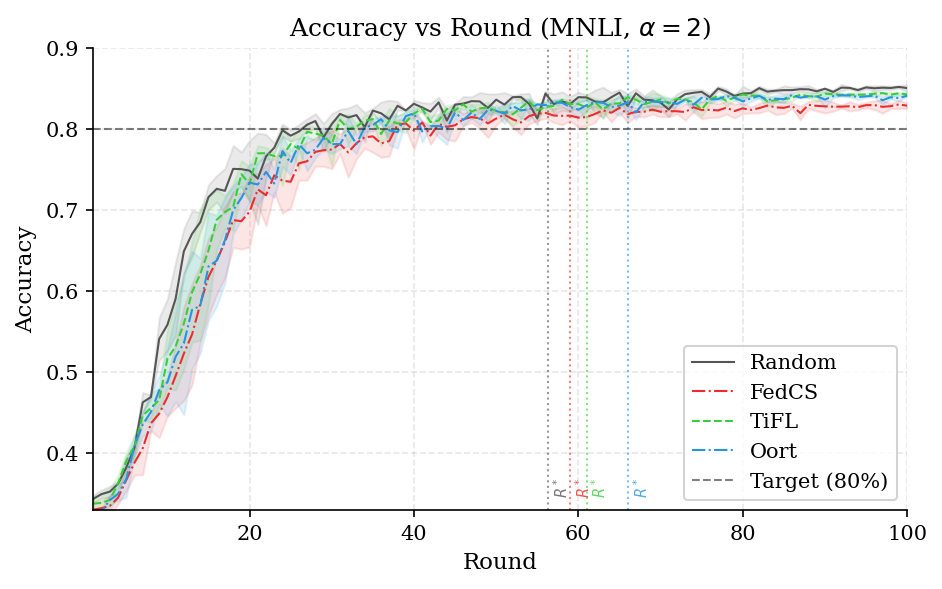

Saved → results/figures/g1_acc_round.[pdf|png]


In [113]:
alpha = 2.0

fig, ax = plt.subplots(figsize=(7, 4))

for strat in STRATEGIES:
    arr = get_series(alpha, strat, "acc_series")
    mu, sigma = mean_std(arr)
    r_star_mu = scalar_agg(alpha, strat, "r_star")[0]

    ax.plot(rounds, mu, color=COLORS[strat], ls=LINES[strat], lw=1.0,
            label=LABELS[strat])
    ax.fill_between(rounds, mu - sigma, mu + sigma,
                    color=COLORS[strat], alpha=0.12)
    ax.axvline(r_star_mu, color=COLORS[strat], ls=":", lw=1.0, alpha=0.6)
    ax.text(r_star_mu + 0.5, 0.345, r"$R^*$", fontsize=7,
            color=COLORS[strat], va="bottom", rotation=90, alpha=0.8)

ax.axhline(TARGET_ACC, color="black", ls="--", lw=1.0, alpha=0.5,
           label=f"Target ({TARGET_ACC:.0%})")
ax.set_xlabel("Round")
ax.set_ylabel("Accuracy")
ax.set_xlim(1, R_MAX)
ax.set_ylim(0.33, 0.90)
ax.legend(loc="lower right", framealpha=0.85)
ax.set_title(r"Accuracy vs Round (MNLI, $\alpha{=}2$)")
savefig("g1_acc_round")

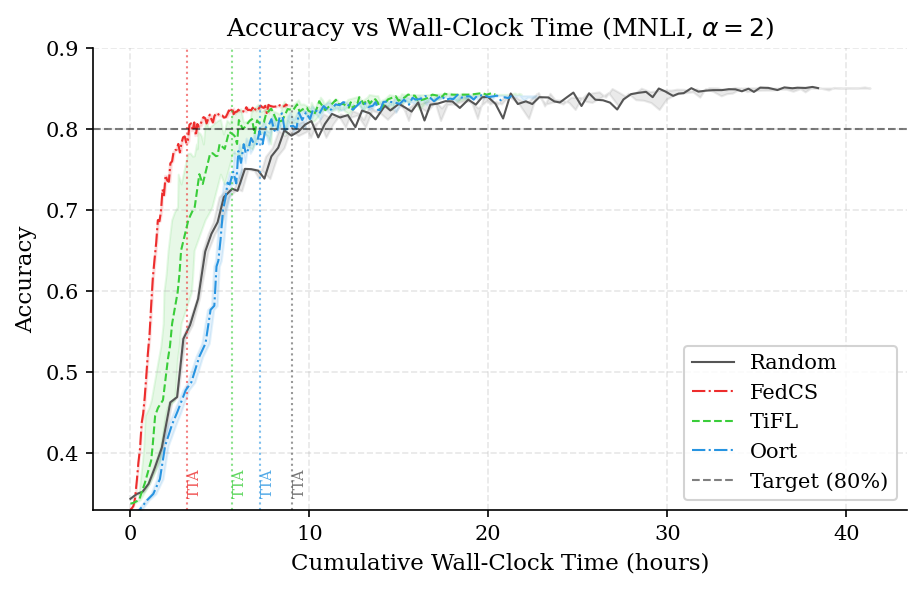

Saved → results/figures/g1_acc_wallclock.[pdf|png]


In [114]:
fig, ax = plt.subplots(figsize=(7, 4))

for strat in STRATEGIES:
    acc_arr = get_series(alpha, strat, "acc_series")
    wc_arr  = get_series(alpha, strat, "cum_wc_series") / 3600
    wc_mu,  wc_sd  = mean_std(wc_arr)
    acc_mu, acc_sd = mean_std(acc_arr)

    ax.plot(wc_mu, acc_mu, color=COLORS[strat], ls=LINES[strat],
            lw=1.0, label=LABELS[strat])
    ax.fill_betweenx(acc_mu, wc_mu - wc_sd, wc_mu + wc_sd,
                     color=COLORS[strat], alpha=0.12)

    tta_mu = scalar_agg(alpha, strat, "tta")[0]
    if not np.isnan(tta_mu):
        tta_h = tta_mu / 3600
        ax.axvline(tta_h, color=COLORS[strat], ls=":", lw=1.0, alpha=0.6)
        ax.text(tta_h + 0.05, 0.345, "TTA", fontsize=7,
                color=COLORS[strat], va="bottom", rotation=90, alpha=0.8)

ax.axhline(TARGET_ACC, color="black", ls="--", lw=1.0, alpha=0.5,
           label=f"Target ({TARGET_ACC:.0%})")
ax.set_xlabel("Cumulative Wall-Clock Time (hours)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.33, 0.90)
ax.legend(loc="lower right", framealpha=0.85)
ax.set_title(r"Accuracy vs Wall-Clock Time (MNLI, $\alpha{=}2$)")
savefig("g1_acc_wallclock")

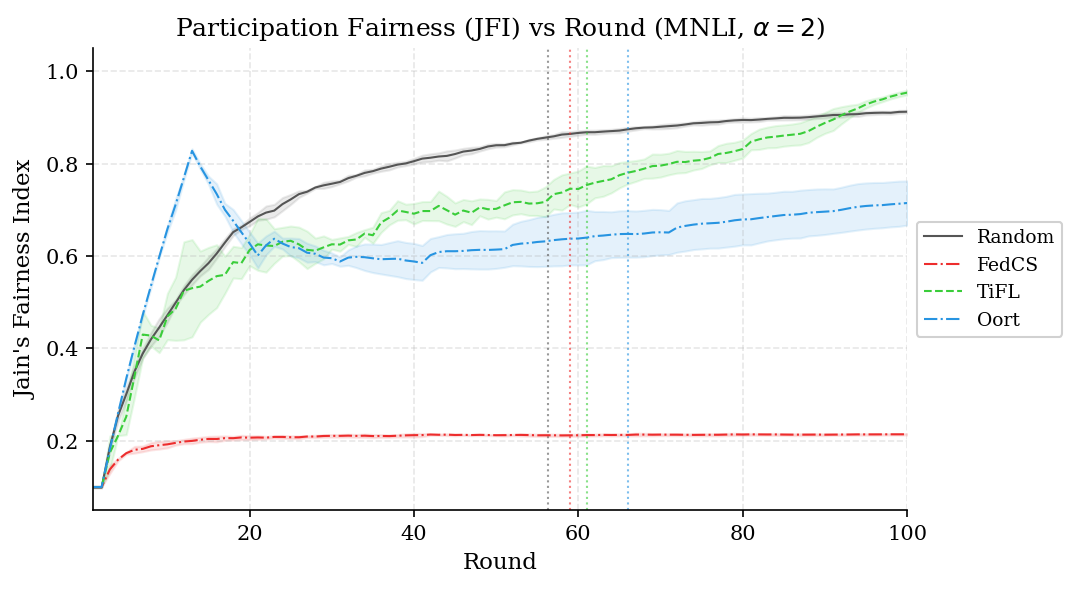

Saved → results/figures/g1_jfi_round.[pdf|png]


In [115]:
fig, ax = plt.subplots(figsize=(7, 4))

for strat in STRATEGIES:
    arr = get_series(alpha, strat, "jfi_series")
    mu, sigma = mean_std(arr)
    r_star_mu = scalar_agg(alpha, strat, "r_star")[0]

    ax.plot(rounds, mu, color=COLORS[strat], ls=LINES[strat],
            lw=1.0, label=LABELS[strat])
    ax.fill_between(rounds, mu - sigma, mu + sigma,
                    color=COLORS[strat], alpha=0.12)
    if not np.isnan(r_star_mu):
        ax.axvline(r_star_mu, color=COLORS[strat], ls=":", lw=1.0, alpha=0.6)

ax.set_xlabel("Round")
ax.set_ylabel("Jain's Fairness Index")
ax.set_xlim(1, R_MAX)
ax.set_ylim(0.05, 1.05)
legend_outside(ax)
ax.set_title(r"Participation Fairness (JFI) vs Round (MNLI, $\alpha{=}2$)")
savefig("g1_jfi_round")

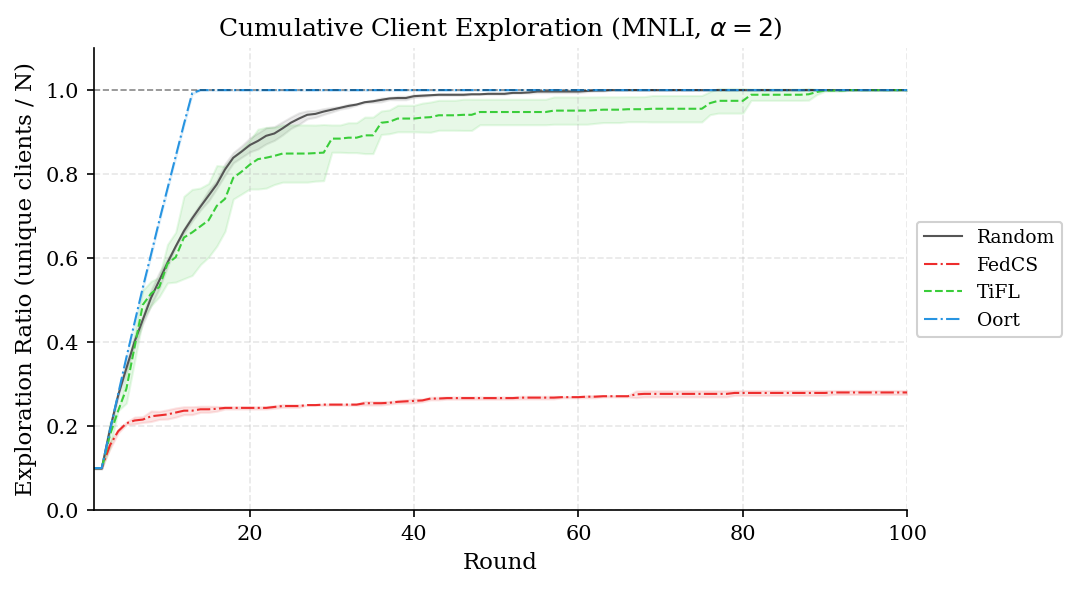

Saved → results/figures/g1_exploration.[pdf|png]


In [116]:
fig, ax = plt.subplots(figsize=(7, 4))

for strat in STRATEGIES:
    arr = get_series(alpha, strat, "unique_exp_series") / N_CLIENTS
    mu, sigma = mean_std(arr)

    ax.plot(rounds, mu, color=COLORS[strat], ls=LINES[strat],
            lw=1.0, label=LABELS[strat])
    ax.fill_between(rounds, mu - sigma, mu + sigma,
                    color=COLORS[strat], alpha=0.12)

ax.axhline(1.0, color="black", ls="--", lw=0.8, alpha=0.4)
ax.set_xlabel("Round")
ax.set_ylabel("Exploration Ratio (unique clients / N)")
ax.set_xlim(1, R_MAX)
ax.set_ylim(0, 1.10)
legend_outside(ax)
ax.set_title(r"Cumulative Client Exploration (MNLI, $\alpha{=}2$)")
savefig("g1_exploration")

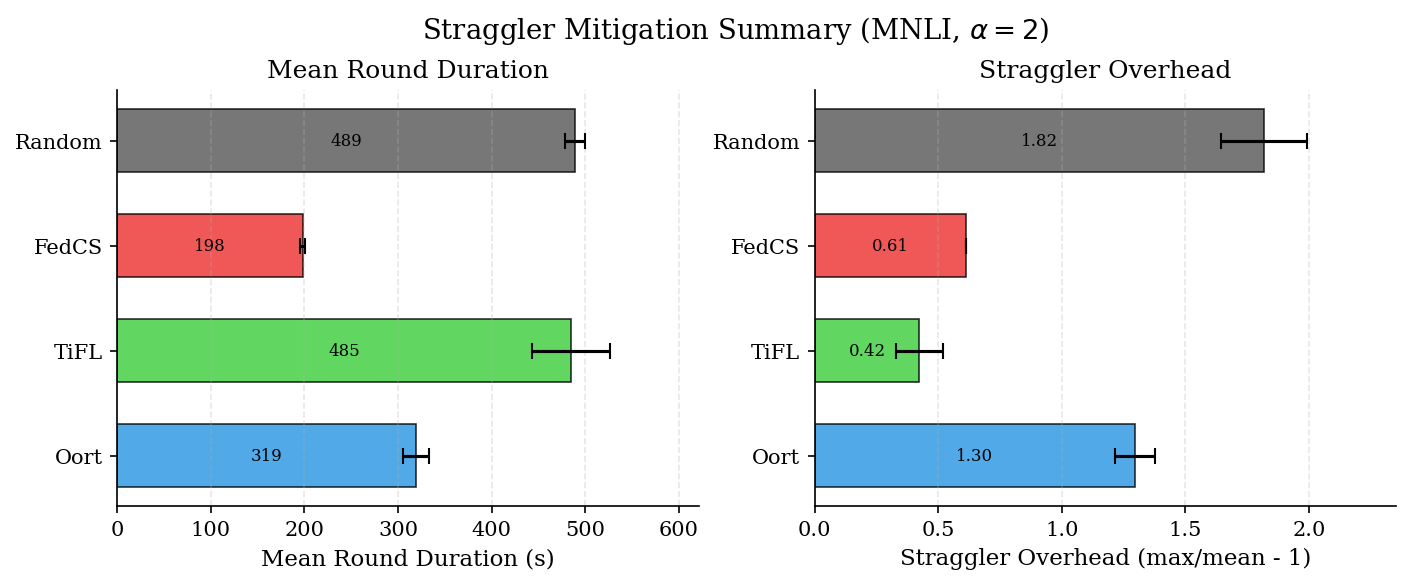

Saved → results/figures/g1_straggler.[pdf|png]


In [117]:
# ===== g1_straggler (alpha=2, MRD + StragOH), horizontal =====
y = np.arange(len(STRATEGIES))[::-1]          # Random at top ... Oort at bottom
colors = [COLORS[s] for s in STRATEGIES]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

panels = [("mean_round_dur", "Mean Round Duration (s)", "Mean Round Duration", 0),
          ("strag_overhead", "Straggler Overhead (max/mean - 1)", "Straggler Overhead", 2)]
for ax, (key, xlabel, title, dec) in zip(axes, panels):
    vals = [scalar_agg(alpha, s, key)[0] for s in STRATEGIES]
    errs = [(lambda sd: sd if not np.isnan(sd) else 0.0)(scalar_agg(alpha, s, key)[1])
            for s in STRATEGIES]
    vmax = max(v + e for v, e in zip(vals, errs))
    ax.set_xlim(0, vmax * 1.18)               # headroom for sigma labels
    bars = ax.barh(y, vals, height=0.6, xerr=errs, capsize=4,
                   color=colors, alpha=0.8, edgecolor="black", lw=0.8)
    annotate_bars(ax, bars, vals,
                  stds=[e if e > 0 else np.nan for e in errs], dec=dec, orient="h")
    ax.set_yticks(y); ax.set_yticklabels([LABELS[s] for s in STRATEGIES])
    ax.set_xlabel(xlabel); ax.set_title(title)
    ax.grid(axis="x", alpha=0.3, ls="--"); ax.grid(axis="y", visible=False)

fig.suptitle(r"Straggler Mitigation Summary (MNLI, $\alpha{=}2$)", y=1.02)
savefig("g1_straggler")


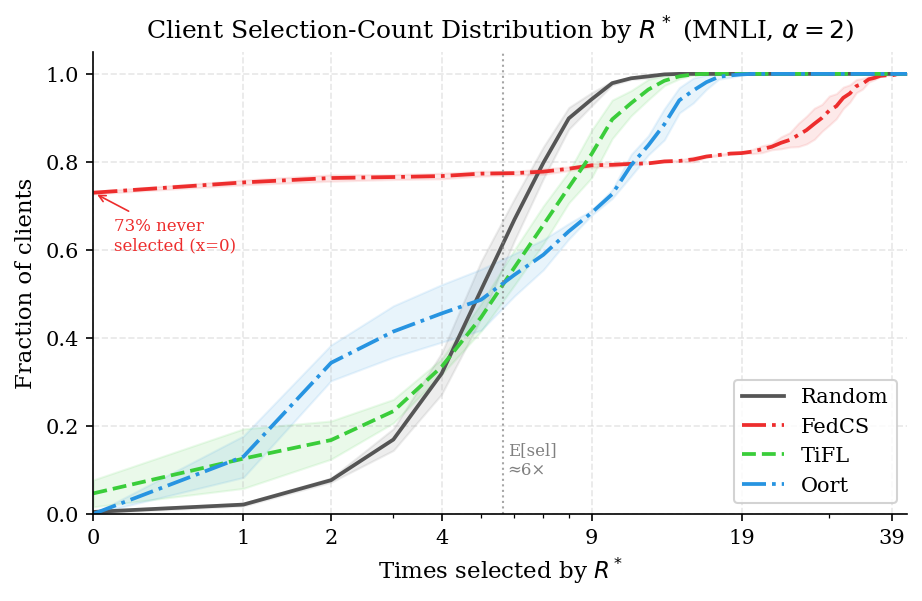

Saved → results/figures/g1_sel_histogram.[pdf|png]


In [118]:
# %% Fig 11 — Participation CDF by R* (α=2 only, log x-axis)

fig, ax = plt.subplots(figsize=(7, 4))
alpha = 2.0

# ── Pre-compute global max so xlim covers all strategies ────────────────
global_max = 0
for strat in STRATEGIES:
    for seed in _get_seeds(alpha, strat):
        counts = D[alpha][strat][seed].get("sel_counts_r_star")
        if counts is not None:
            global_max = max(global_max, int(counts.max()))

for strat in STRATEGIES:
    seeds = _get_seeds(alpha, strat)
    seed_cdfs = []
    for seed in seeds:
        m = D[alpha][strat][seed]
        counts = m.get("sel_counts_r_star")
        if counts is None:
            continue
        xs  = np.arange(0, global_max + 2)
        cdf = np.array([(counts <= x).mean() for x in xs])
        seed_cdfs.append(cdf)

    if not seed_cdfs:
        continue

    mean_cdf = np.mean(seed_cdfs, axis=0)
    std_cdf  = np.std(seed_cdfs, axis=0) if len(seed_cdfs) > 1 else np.zeros_like(mean_cdf)
    xs_log   = np.arange(global_max + 2) + 1   # shift +1 for log axis

    ax.plot(xs_log, mean_cdf,
            color=COLORS[strat], ls=LINES[strat], lw=1.8,
            label=LABELS[strat])
    ax.fill_between(xs_log, mean_cdf - std_cdf, mean_cdf + std_cdf,
                    color=COLORS[strat], alpha=0.10)

# Expected mean reference line
r_star_mu = scalar_agg(alpha, "random", "r_star")[0]
if not np.isnan(r_star_mu):
    expected_mean = K * r_star_mu / N_CLIENTS
    ax.axvline(expected_mean + 1, color="gray", ls=":", lw=1.0, alpha=0.7)
    ax.text(expected_mean + 1.15, 0.08,
            f"E[sel]\n≈{expected_mean:.0f}×",
            fontsize=8, color="gray", va="bottom")
    

ax.annotate("73% never\nselected (x=0)",
            xy=(1, 0.73), xytext=(1.1, 0.60),
            fontsize=8, color=COLORS["fedcs"],
            arrowprops=dict(arrowstyle="->", color=COLORS["fedcs"], lw=0.8))

ax.set_xscale("log")

tick_positions = [1, 2, 3, 5, 10, 20, 40]
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(t - 1) for t in tick_positions])

ax.set_xlabel("Times selected by $R^*$")
ax.set_ylabel("Fraction of clients")
ax.set_xlim(1, global_max + 2)
ax.set_ylim(0, 1.05)
ax.legend(framealpha=0.85, fontsize=10, loc="lower right")
ax.set_title(r"Client Selection-Count Distribution by $R^*$ (MNLI, $\alpha{=}2$)")

savefig("g1_sel_histogram")

---
## Group 2 Figures (Cross-Alpha Comparison)

In [119]:
def _draw_panel(ax, alpha, series_key, y_label=None, y_lim=None,
                r_star_lines=True, target_line=False, title=None,
                legend=False):
    for strat in STRATEGIES:
        arr = get_series(alpha, strat, series_key)
        mu, sigma = mean_std(arr)
        seeds = _get_seeds(alpha, strat)

        ax.plot(rounds, mu, color=COLORS[strat], ls=LINES[strat],
                lw=1.0, label=LABELS[strat])
        if len(seeds) > 1:
            ax.fill_between(rounds, mu - sigma, mu + sigma,
                            color=COLORS[strat], alpha=0.12)

        if r_star_lines:
            r_star_mu = scalar_agg(alpha, strat, "r_star")[0]
            if not np.isnan(r_star_mu):
                ax.axvline(r_star_mu, color=COLORS[strat], ls=":",
                           lw=0.9, alpha=0.6)

    if target_line:
        ax.axhline(TARGET_ACC, color="black", ls="--", lw=0.9, alpha=0.5)
    ax.set_xlabel("Round")
    ax.set_xlim(1, R_MAX)
    if y_label:
        ax.set_ylabel(y_label)
    if y_lim:
        ax.set_ylim(*y_lim)
    if title:
        ax.set_title(title)
    if legend:
        ax.legend(loc="lower right", framealpha=0.85, fontsize=9)

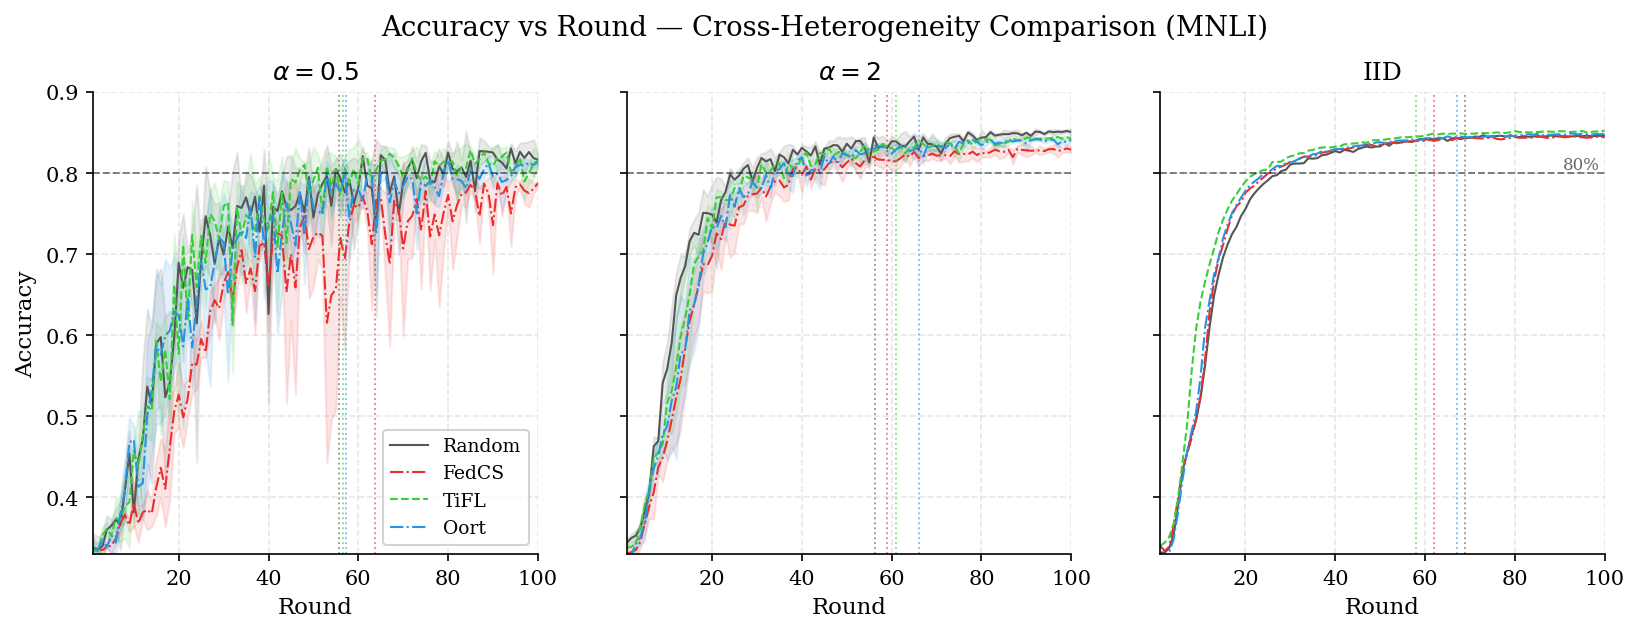

Saved → results/figures/g2_acc_round.[pdf|png]


In [120]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for i, alpha in enumerate(ALPHAS):
    show_legend = (i == 0)
    show_ylabel = (i == 0)
    _draw_panel(axes[i], alpha, "acc_series",
                y_label="Accuracy" if show_ylabel else None,
                y_lim=(0.33, 0.90),
                target_line=True,
                title=ALPHA_LABELS[alpha],
                legend=show_legend)

# Add target label to last panel only
axes[2].text(R_MAX - 1, TARGET_ACC + 0.005, f"{TARGET_ACC:.0%}",
             ha="right", fontsize=8, alpha=0.6)
fig.suptitle("Accuracy vs Round — Cross-Heterogeneity Comparison (MNLI)", y=1.01)
savefig("g2_acc_round")

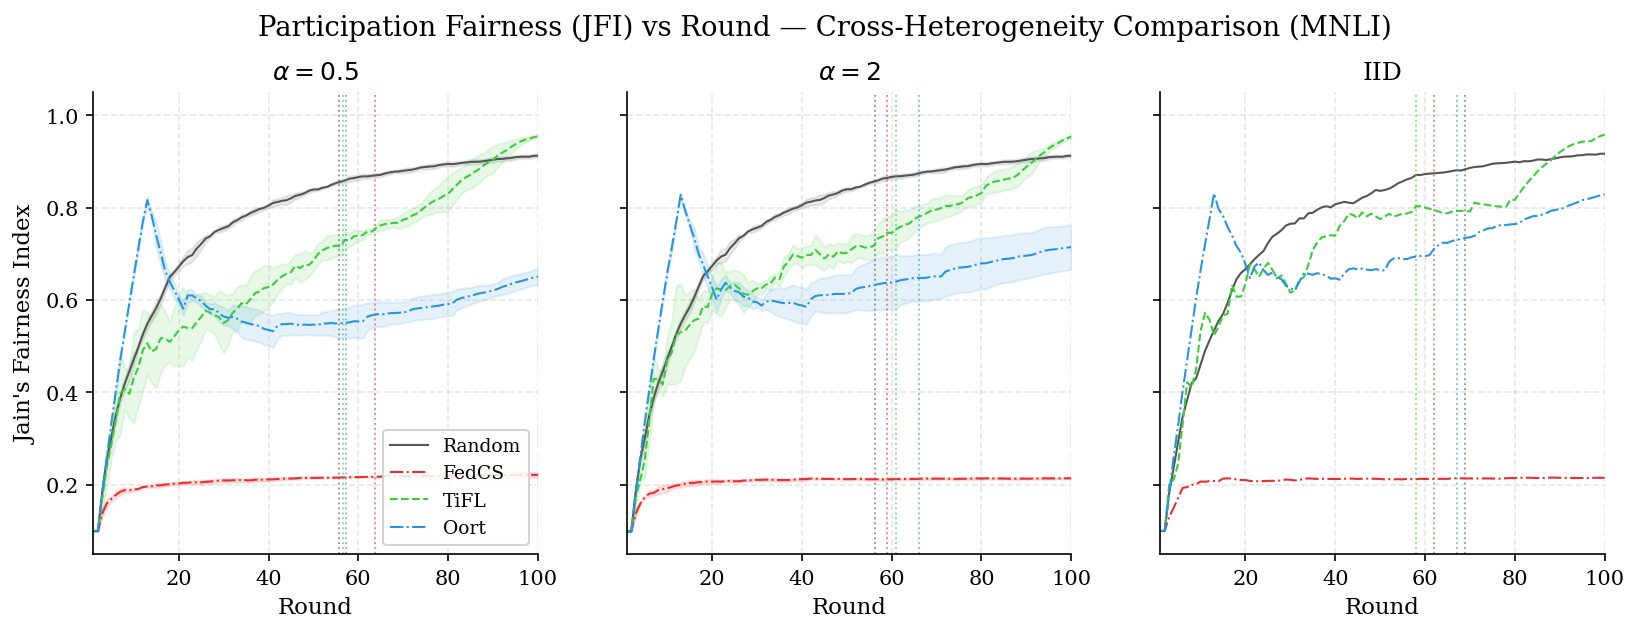

Saved → results/figures/g2_jfi_round.[pdf|png]


In [121]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for i, alpha in enumerate(ALPHAS):
    show_legend = (i == 0)
    show_ylabel = (i == 0)
    _draw_panel(axes[i], alpha, "jfi_series",
                y_label="Jain's Fairness Index" if show_ylabel else None,
                y_lim=(0.05, 1.05),
                title=ALPHA_LABELS[alpha],
                legend=show_legend)

fig.suptitle("Participation Fairness (JFI) vs Round — Cross-Heterogeneity Comparison (MNLI)", y=1.01)
savefig("g2_jfi_round")

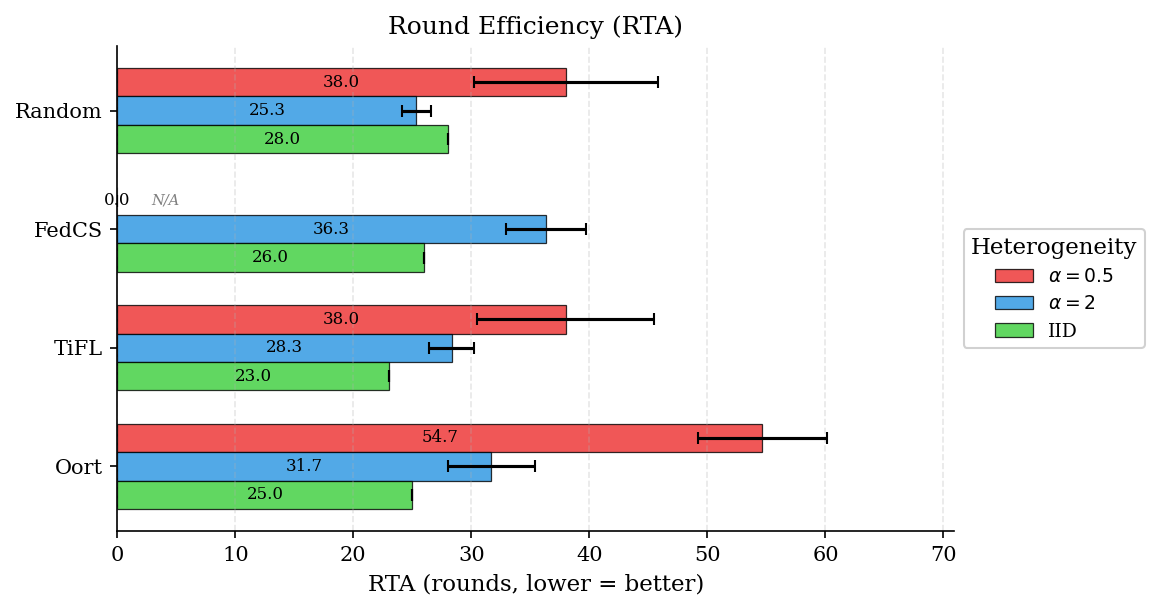

Saved → results/figures/g2_rta.[pdf|png]


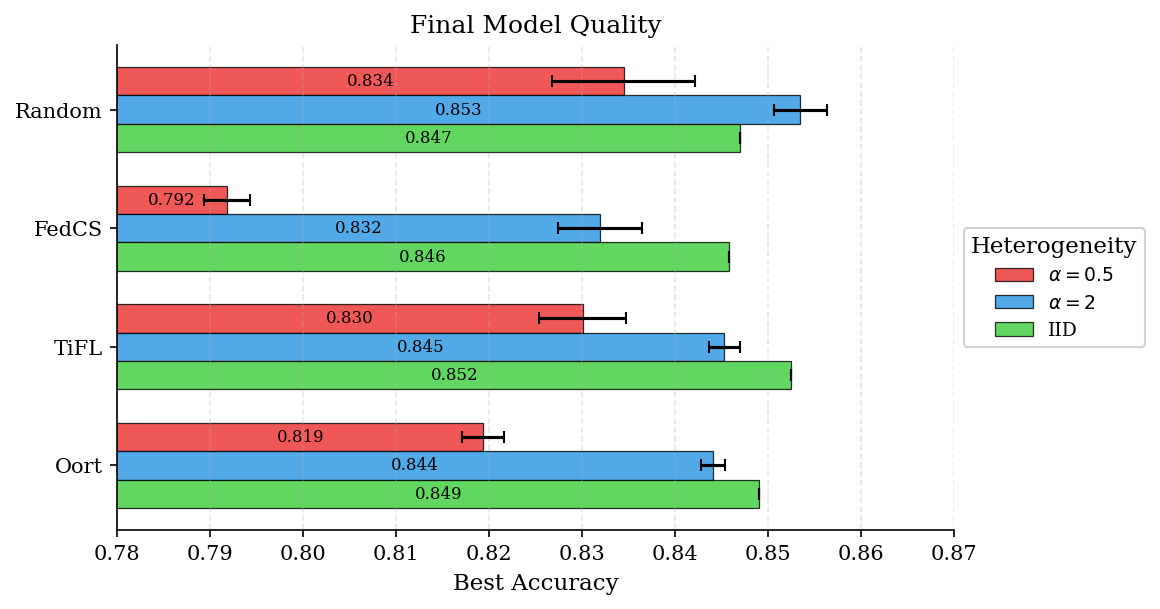

Saved → results/figures/g2_bestacc.[pdf|png]


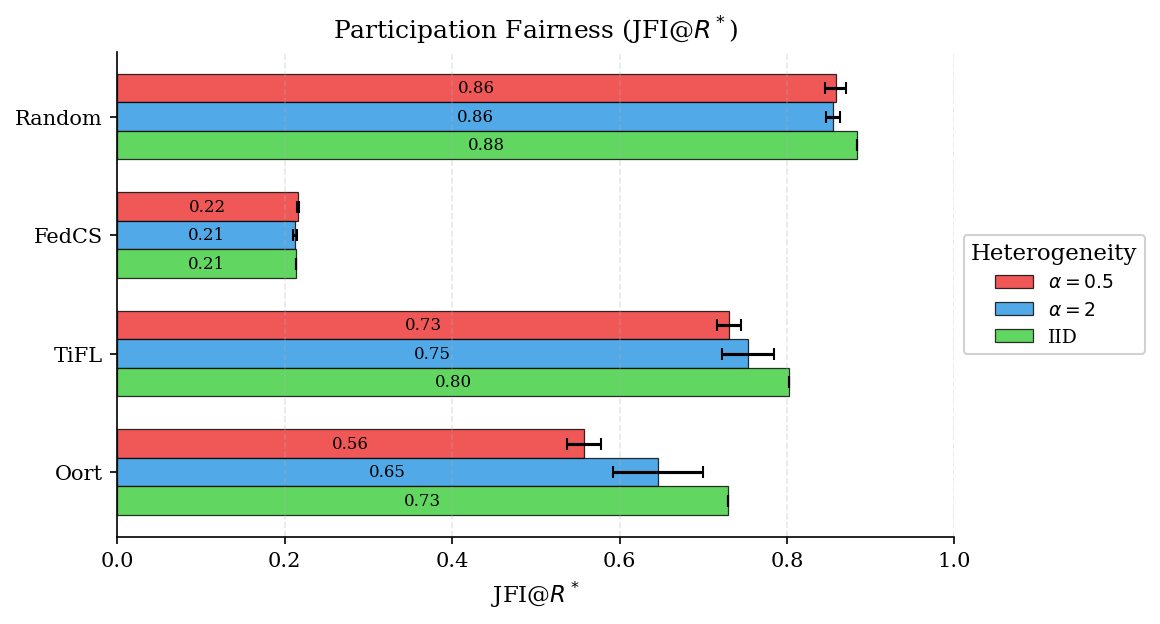

Saved → results/figures/g2_jfi_rstar.[pdf|png]


In [122]:
def _cross_alpha_barh(key, xlabel, title, fname, xlim=None, na_fedcs_05=False,
                      dec=2, hours=False, figsize=(7.2, 4.2)):
    """Horizontal grouped bars: one strategy block, alpha sub-bars within."""
    y = np.arange(len(STRATEGIES))[::-1]          # top-to-bottom = Random..Oort
    n_alpha = len(ALPHAS); height = 0.24
    offsets = np.linspace((n_alpha - 1)/2, -(n_alpha - 1)/2, n_alpha) * height
    fig, ax = plt.subplots(figsize=figsize)
    if xlim:
        ax.set_xlim(*xlim)
    else:
        _vm = 0.0
        for _a in ALPHAS:
            for _s in STRATEGIES:
                if hours: _m,_e = _tta_hours(_a,_s)
                else: _m,_e = scalar_agg(_a,_s,key)
                if not np.isnan(_m): _vm = max(_vm, _m + (0 if np.isnan(_e) else _e))
        ax.set_xlim(0, _vm * 1.18)
    for j, alpha in enumerate(ALPHAS):
        vals, errs = [], []
        for strat in STRATEGIES:
            if hours:
                mu, sd = _tta_hours(alpha, strat)
            else:
                mu, sd = scalar_agg(alpha, strat, key)
            if na_fedcs_05 and np.isnan(mu):
                mu, sd = 0.0, 0.0
            vals.append(0.0 if np.isnan(mu) else mu)
            errs.append(sd if not np.isnan(sd) else 0.0)
        bars = ax.barh(y + offsets[j], vals, height=height, xerr=errs, capsize=3,
                       color=ALPHA_COLORS[alpha], alpha=0.8, edgecolor="black",
                       lw=0.6, label=ALPHA_LABELS[alpha])
        annotate_bars(ax, bars, vals,
                      stds=[e if e > 0 else np.nan for e in errs],
                      dec=dec, orient="h")
        if na_fedcs_05 and alpha == 0.5:
            bars[STRATEGIES.index("fedcs")].set_hatch("//")
            bars[STRATEGIES.index("fedcs")].set_alpha(0.3)
    ax.set_yticks(y); ax.set_yticklabels([LABELS[s] for s in STRATEGIES])
    ax.set_xlabel(xlabel); ax.set_title(title)
    ax.grid(axis="x", alpha=0.3, ls="--"); ax.grid(axis="y", visible=False)
    legend_outside(ax, title="Heterogeneity")
    if na_fedcs_05:
        fy = y[STRATEGIES.index("fedcs")] + offsets[ALPHAS.index(0.5)]
        ax.text((xlim[1] if xlim else ax.get_xlim()[1]) * 0.04, fy,
                "N/A", ha="left", va="center", fontsize=7,
                color="gray", style="italic")
    savefig(fname)

_cross_alpha_barh("rta", "RTA (rounds, lower = better)", "Round Efficiency (RTA)",
                  "g2_rta", na_fedcs_05=True, dec=1)
# Best accuracy spans a narrow band (~0.79-0.85); zoom the x-axis so the bars
# are distinguishable, and label with absolute values.
_cross_alpha_barh("best_acc", "Best Accuracy", "Final Model Quality",
                  "g2_bestacc", xlim=(0.78, 0.87), dec=3)
_cross_alpha_barh("jfi_at_r_star", r"JFI@$R^*$", r"Participation Fairness (JFI@$R^*$)",
                  "g2_jfi_rstar", xlim=(0, 1.0), dec=2)


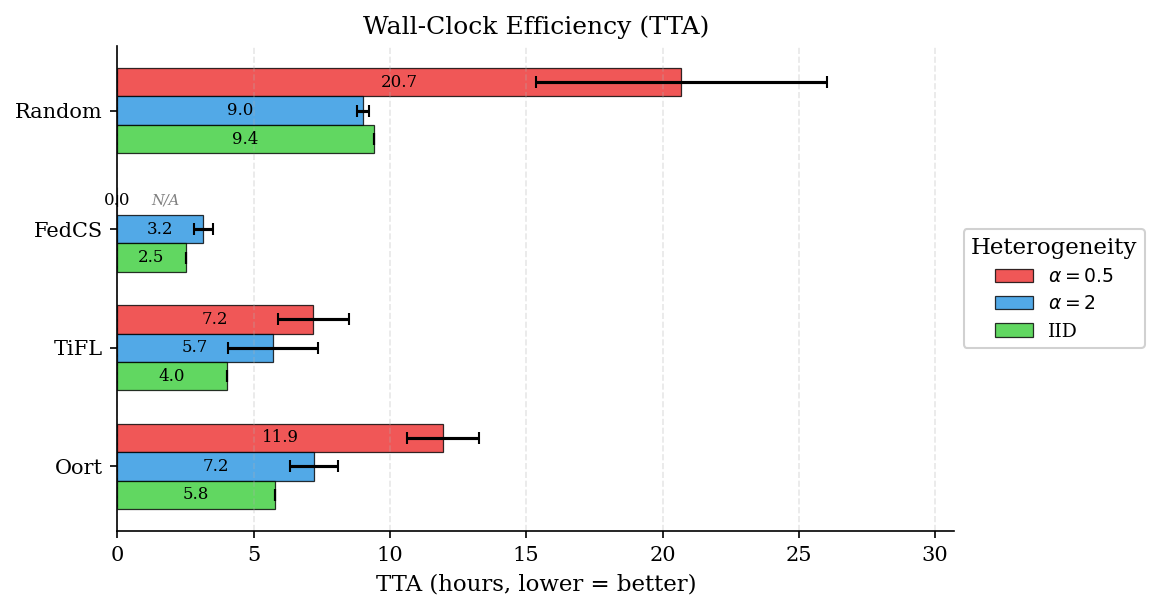

Saved → results/figures/g2_tta.[pdf|png]


In [123]:
def _tta_hours(alpha, strat):
    vals = [D[alpha][strat][s]["tta"]/3600 for s in _get_seeds(alpha, strat)
            if D[alpha][strat][s].get("tta") is not None]
    if not vals:
        return np.nan, np.nan
    return float(np.mean(vals)), (float(np.std(vals)) if len(vals) > 1 else 0.0)

_cross_alpha_barh(None, "TTA (hours, lower = better)", "Wall-Clock Efficiency (TTA)",
                  "g2_tta", na_fedcs_05=True, dec=1, hours=True)


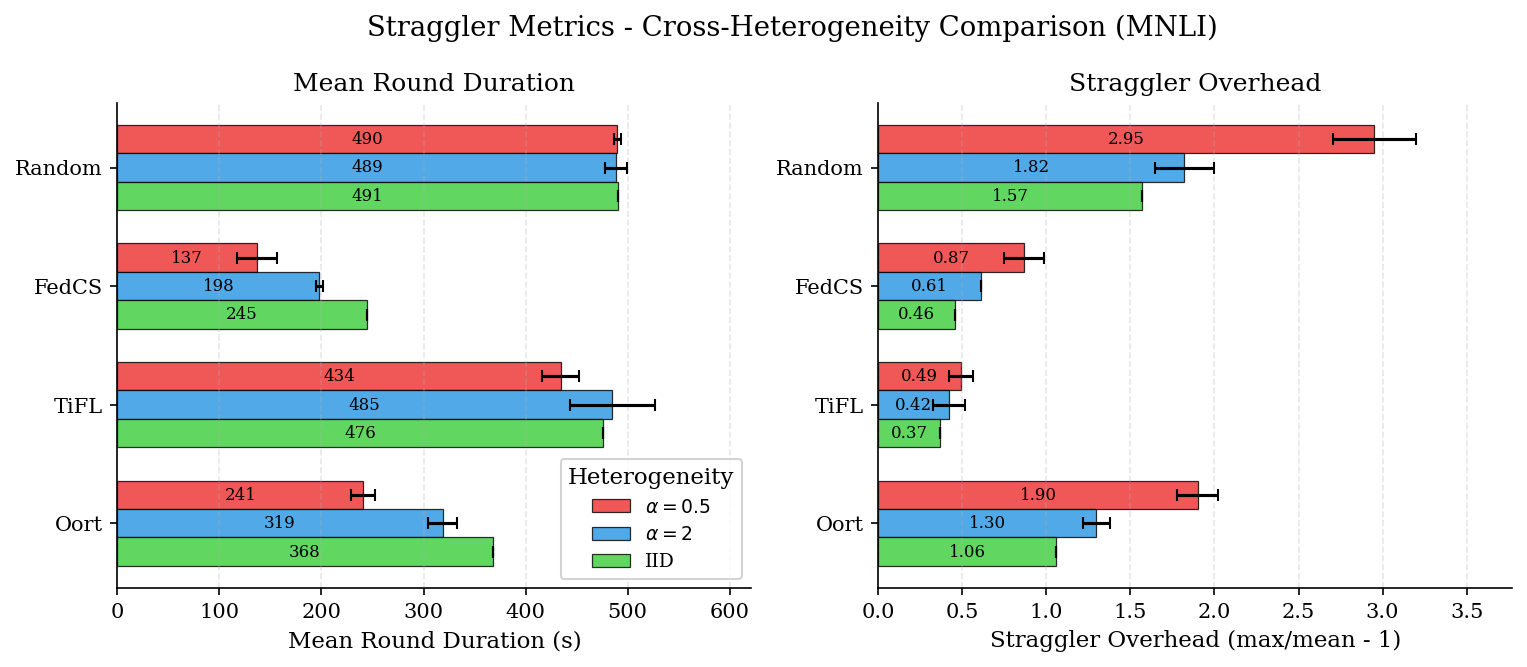

Saved → results/figures/g2_straggler.[pdf|png]


In [124]:
# ===== g2_straggler (cross-alpha MRD + StragOH), horizontal =====
y = np.arange(len(STRATEGIES))[::-1]
n_alpha = len(ALPHAS); height = 0.24
offsets = np.linspace((n_alpha - 1)/2, -(n_alpha - 1)/2, n_alpha) * height
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
panels = [("mean_round_dur", "Mean Round Duration (s)", "Mean Round Duration", 0),
          ("strag_overhead", "Straggler Overhead (max/mean - 1)", "Straggler Overhead", 2)]
for ax, (key, xlabel, title, dec) in zip(axes, panels):
    series = {}
    vmax = 0.0
    for alpha in ALPHAS:
        vals = [scalar_agg(alpha, s, key)[0] for s in STRATEGIES]
        errs = [(lambda sd: sd if not np.isnan(sd) else 0.0)(scalar_agg(alpha, s, key)[1])
                for s in STRATEGIES]
        series[alpha] = (vals, errs)
        vmax = max(vmax, max((v + e) for v, e in zip(vals, errs)))
    ax.set_xlim(0, vmax * 1.18)          # headroom for the sigma labels
    for j, alpha in enumerate(ALPHAS):
        vals, errs = series[alpha]
        bars = ax.barh(y + offsets[j], vals, height=height, xerr=errs, capsize=3,
                       color=ALPHA_COLORS[alpha], alpha=0.8, edgecolor="black",
                       lw=0.6, label=ALPHA_LABELS[alpha])
        annotate_bars(ax, bars, vals,
                      stds=[e if e > 0 else np.nan for e in errs], dec=dec, orient="h")
    ax.set_yticks(y); ax.set_yticklabels([LABELS[s] for s in STRATEGIES])
    ax.set_xlabel(xlabel); ax.set_title(title)
    ax.grid(axis="x", alpha=0.3, ls="--"); ax.grid(axis="y", visible=False)
    if ax is axes[0]:
        ax.legend(title="Heterogeneity", framealpha=0.85, fontsize=9, loc="lower right")
fig.suptitle(r"Straggler Metrics - Cross-Heterogeneity Comparison (MNLI)", y=1.02)
savefig("g2_straggler")


---
## RQ2 Mechanism Figures

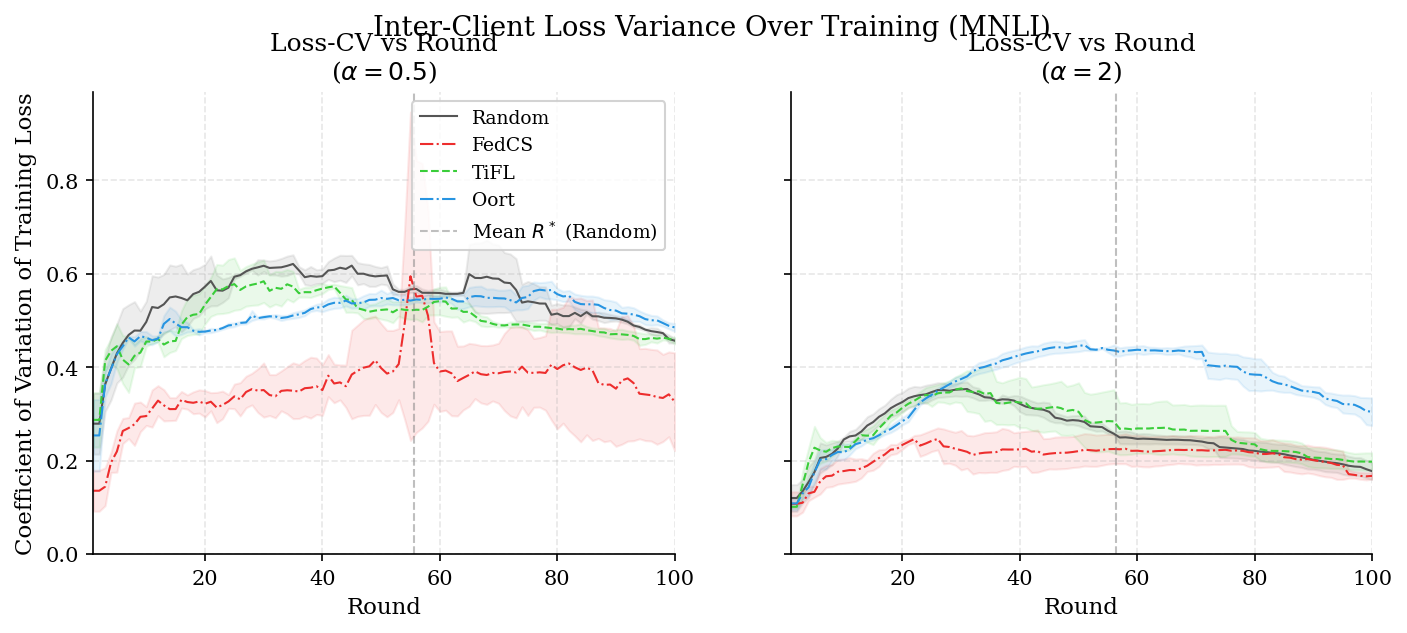

Saved → results/figures/rq2_loss_cv.[pdf|png]


In [125]:
#
# Shows how inter-client loss variance collapses over training rounds.
# Under pretrained LoRA, loss-CV compresses fast → utility signal
# becomes less discriminative → explains Oort's round-efficiency parity with Random.

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, alpha in zip(axes, [0.5, 2.0]):
    for strat in STRATEGIES:
        arr = get_series(alpha, strat, "loss_cv_series")
        mu, sigma = mean_std(arr)
        seeds = _get_seeds(alpha, strat)

        ax.plot(rounds, mu, color=COLORS[strat], ls=LINES[strat],
                lw=1.0, label=LABELS[strat])
        if len(seeds) > 1:
            ax.fill_between(rounds, mu - sigma, mu + sigma,
                            color=COLORS[strat], alpha=0.10)

    r_star_mu = scalar_agg(alpha, "random", "r_star")[0]
    if not np.isnan(r_star_mu):
        ax.axvline(r_star_mu, color="gray", ls="--", lw=1.0, alpha=0.5,
                   label=r"Mean $R^*$ (Random)")
    ax.set_xlabel("Round")
    ax.set_xlim(1, R_MAX)
    ax.set_ylim(bottom=0)
    ax.set_title(f"Loss-CV vs Round\n({ALPHA_LABELS[alpha]})")

axes[0].set_ylabel("Coefficient of Variation of Training Loss")
axes[0].legend(loc="upper right", framealpha=0.85, fontsize=9)
fig.suptitle("Inter-Client Loss Variance Over Training (MNLI)", y=1.01)
savefig("rq2_loss_cv")

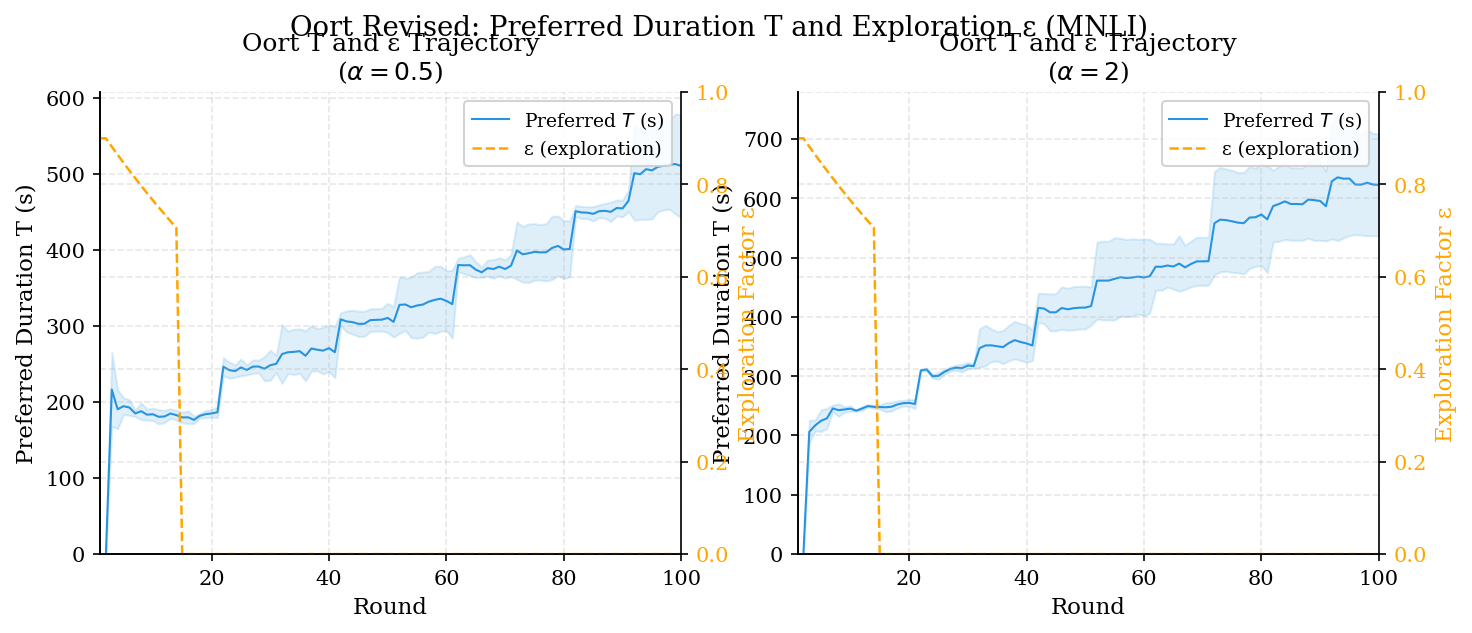

Saved → results/figures/rq2_oort_t.[pdf|png]


In [126]:
#
# Verifies the revised percentile-T Oort is actively adapting.
# T should start small, fire on many clients, then relax upward via pacer.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, alpha in zip(axes, [0.5, 2.0]):
    # T trajectory (left y-axis)
    arr_t = get_series(alpha, "oort", "oort_preferred_t_series")
    mu_t, sd_t = mean_std(arr_t)
    seeds = _get_seeds(alpha, "oort")

    line_t = ax.plot(rounds, mu_t, color=COLORS["oort"], lw=1.0,
                     label=r"Preferred $T$ (s)", zorder=3)
    if len(seeds) > 1:
        ax.fill_between(rounds, mu_t - sd_t, mu_t + sd_t,
                        color=COLORS["oort"], alpha=0.15)
    ax.set_ylabel("Preferred Duration T (s)")
    ax.set_xlabel("Round")
    ax.set_xlim(1, R_MAX)
    ax.set_ylim(bottom=0)

    # ε trajectory (right y-axis)
    ax2 = ax.twinx()
    arr_e = get_series(alpha, "oort", "oort_epsilon_series")
    mu_e, sd_e = mean_std(arr_e)
    line_e = ax2.plot(rounds, mu_e, color="orange", ls="--", lw=1.2,
                      label="ε (exploration)", zorder=2)
    ax2.set_ylabel("Exploration Factor ε", color="orange")
    ax2.tick_params(axis="y", labelcolor="orange")
    ax2.set_ylim(0, 1)
    ax2.spines["right"].set_visible(True)

    # Combine legends
    lines = line_t + line_e
    labs  = [l.get_label() for l in lines]
    ax.legend(lines, labs, loc="upper right", fontsize=9, framealpha=0.85)
    ax.set_title(f"Oort T and ε Trajectory\n({ALPHA_LABELS[alpha]})")

fig.suptitle("Oort Revised: Preferred Duration T and Exploration ε (MNLI)", y=1.01)
savefig("rq2_oort_t")

---
## LaTeX Tables

In [127]:
def _fmt(mu, sd, dec=2, signed=False):
    if np.isnan(mu):
        return r"\textemdash"
    sign = "+" if signed and mu > 0 else ""
    if np.isnan(sd) or sd == 0:
        return f"${sign}{mu:.{dec}f}$"
    return f"${sign}{mu:.{dec}f} \\pm {sd:.{dec}f}$"

def _bold(s, condition):
    """Wrap in \textbf if condition is True."""
    return f"\\textbf{{{s}}}" if condition else s

In [128]:
alpha = 2.0
col_headers = ["Strategy", r"$R^*$", "RTA", "MRD (s)", "Strag. OH", "TTA (h)"]

def _rel(mu, base):  # relative % vs Random, for lower-is-better rate metrics
    if np.isnan(mu) or base in (0, None) or np.isnan(base): return ""
    d = 100*(mu-base)/base
    return f" ({d:+.0f}\\%)"

rand = {k: scalar_agg(alpha, "random", k)[0]
        for k in ["rta", "mean_round_dur", "strag_overhead"]}
rand_tta = _tta_hours(alpha, "random")[0]

rows = []
for strat in STRATEGIES:
    rs  = scalar_agg(alpha, strat, "r_star")
    rta = scalar_agg(alpha, strat, "rta")
    mrd = scalar_agg(alpha, strat, "mean_round_dur")
    soh = scalar_agg(alpha, strat, "strag_overhead")
    tta_mu, tta_sd = _tta_hours(alpha, strat)
    is_rand = strat == "random"
    rows.append([
        LABELS[strat],
        _fmt(*rs, 1),
        _fmt(*rta, 1) + ("" if is_rand else _rel(rta[0], rand["rta"])),
        _fmt(*mrd, 0) + ("" if is_rand else _rel(mrd[0], rand["mean_round_dur"])),
        _fmt(*soh, 2) + ("" if is_rand else _rel(soh[0], rand["strag_overhead"])),
        _fmt(tta_mu, tta_sd, 2) + ("" if is_rand else _rel(tta_mu, rand_tta)),
    ])

tex = [r"\begin{tabular}{lccccc}", r"\toprule",
       " & ".join(col_headers) + r" \\", r"\midrule"]
tex += [" & ".join(r) + r" \\" for r in rows]
tex += [r"\bottomrule", r"\end{tabular}"]
table1 = "\n".join(tex)
print(table1)
open("results/mnli_table1_efficiency.tex", "w").write(table1)

\begin{tabular}{lccccc}
\toprule
Strategy & $R^*$ & RTA & MRD (s) & Strag. OH & TTA (h) \\
\midrule
Random & $56.3 \pm 2.5$ & $25.3 \pm 1.2$ & $489 \pm 11$ & $1.82 \pm 0.18$ & $9.02 \pm 0.22$ \\
FedCS & $59.0 \pm 3.6$ & $36.3 \pm 3.4$ (+43\%) & $198 \pm 3$ (-59\%) & $0.61 \pm 0.00$ (-66\%) & $3.16 \pm 0.36$ (-65\%) \\
TiFL & $61.0 \pm 3.6$ & $28.3 \pm 1.9$ (+12\%) & $485 \pm 42$ (-1\%) & $0.42 \pm 0.09$ (-77\%) & $5.70 \pm 1.64$ (-37\%) \\
Oort & $66.0 \pm 2.4$ & $31.7 \pm 3.7$ (+25\%) & $319 \pm 14$ (-35\%) & $1.30 \pm 0.08$ (-29\%) & $7.23 \pm 0.88$ (-20\%) \\
\bottomrule
\end{tabular}


594

In [129]:
def _abs(mu, base, dec=3):
    if np.isnan(mu) or base is None or np.isnan(base): return ""
    return f" ({mu-base:+.{dec}f})"

randj1 = scalar_agg(alpha, "random", "jfi_at_r_star")[0]
randj2 = scalar_agg(alpha, "random", "jfi_at_r_max")[0]
randns = scalar_agg(alpha, "random", "never_selected")[0]

rows2 = []
for strat in STRATEGIES:
    j1 = scalar_agg(alpha, strat, "jfi_at_r_star")
    j2 = scalar_agg(alpha, strat, "jfi_at_r_max")
    dj = scalar_agg(alpha, strat, "delta_jfi")
    ns = scalar_agg(alpha, strat, "never_selected")
    is_rand = strat == "random"
    rows2.append([
        LABELS[strat],
        _fmt(*j1, 3) + ("" if is_rand else _abs(j1[0], randj1)),
        _fmt(*j2, 3) + ("" if is_rand else _abs(j2[0], randj2)),
        _fmt(*dj, 3, signed=True),
        _fmt(*ns, 0) + ("" if is_rand else _abs(ns[0], randns, dec=0)),
    ])

tex2 = [r"\begin{tabular}{lcccc}", r"\toprule",
        " & ".join(["Strategy", r"JFI@$R^*$", r"JFI@$R_{\max}$",
                    r"$\Delta$JFI", "Never Sel."]) + r" \\", r"\midrule"]
tex2 += [" & ".join(r) + r" \\" for r in rows2]
tex2 += [r"\bottomrule", r"\end{tabular}",]
table2 = "\n".join(tex2)
print(table2)
open("results/mnli_table2_fairness.tex", "w").write(table2)

\begin{tabular}{lcccc}
\toprule
Strategy & JFI@$R^*$ & JFI@$R_{\max}$ & $\Delta$JFI & Never Sel. \\
\midrule
Random & $0.856 \pm 0.008$ & $0.912 \pm 0.003$ & $+0.057 \pm 0.006$ & $1 \pm 1$ \\
FedCS & $0.212 \pm 0.002$ (-0.643) & $0.214 \pm 0.002$ (-0.698) & $+0.002 \pm 0.001$ & $219 \pm 1$ (+218) \\
TiFL & $0.753 \pm 0.031$ (-0.102) & $0.954 \pm 0.005$ (+0.041) & $+0.200 \pm 0.030$ & $14 \pm 9$ (+13) \\
Oort & $0.646 \pm 0.053$ (-0.209) & $0.715 \pm 0.048$ (-0.198) & $+0.068 \pm 0.008$ & $0$ (-1) \\
\bottomrule
\end{tabular}


530

In [135]:
# ── Table 3a: Cross-heterogeneity — Efficiency & Accuracy ─────────────────────
col_headers3a = [
    "Strategy", "Condition", "RTA", "TTA (h)", "Best Acc",
]

tex3a = [r"\begin{tabular}{llccc}", r"\toprule",
         " & ".join(col_headers3a) + r" \\", r"\midrule"]

for strat in STRATEGIES:
    for i, alpha in enumerate(ALPHAS):
        strat_label = LABELS[strat] if i == 0 else ""
        alpha_label = ALPHA_LABELS[alpha]

        rta        = scalar_agg(alpha, strat, "rta")
        tta_mu, tta_sd = _tta_hours(alpha, strat)
        bacc       = scalar_agg(alpha, strat, "best_acc")
        # mrd         = scalar_agg(alpha, strat, "mean_round_dur")
        # strag_oh    = scalar_agg(alpha, strat, "strag_overhead")    

        row = [
            strat_label, alpha_label,
            _fmt(*rta,           dec=1),
            # _fmt(*mrd,           dec=0),
            # _fmt(*strag_oh,      dec=2),
            _fmt(tta_mu, tta_sd, dec=2),
            _fmt(*bacc,          dec=4),
        ]
        tex3a.append("    " + " & ".join(row) + r" \\")

    tex3a.append(r"\midrule")

tex3a[-1] = r"\bottomrule"
tex3a.append(r"\end{tabular}")

table3a = "\n".join(tex3a)
print(table3a)
open("results/mnli_table3a_efficiency.tex", "w").write(table3a)

\begin{tabular}{llccc}
\toprule
Strategy & Condition & RTA & TTA (h) & Best Acc \\
\midrule
    Random & $\alpha{=}0.5$ & $38.0 \pm 7.8$ & $20.69 \pm 5.34$ & $0.8345 \pm 0.0077$ \\
     & $\alpha{=}2$ & $25.3 \pm 1.2$ & $9.02 \pm 0.22$ & $0.8534 \pm 0.0028$ \\
     & IID & $28.0$ & $9.40$ & $0.8470$ \\
\midrule
    FedCS & $\alpha{=}0.5$ & \textemdash & \textemdash & $0.7918 \pm 0.0025$ \\
     & $\alpha{=}2$ & $36.3 \pm 3.4$ & $3.16 \pm 0.36$ & $0.8319 \pm 0.0045$ \\
     & IID & $26.0$ & $2.50$ & $0.8457$ \\
\midrule
    TiFL & $\alpha{=}0.5$ & $38.0 \pm 7.5$ & $7.19 \pm 1.31$ & $0.8300 \pm 0.0047$ \\
     & $\alpha{=}2$ & $28.3 \pm 1.9$ & $5.70 \pm 1.64$ & $0.8453 \pm 0.0016$ \\
     & IID & $23.0$ & $4.01$ & $0.8525$ \\
\midrule
    Oort & $\alpha{=}0.5$ & $54.7 \pm 5.4$ & $11.94 \pm 1.32$ & $0.8193 \pm 0.0022$ \\
     & $\alpha{=}2$ & $31.7 \pm 3.7$ & $7.23 \pm 0.88$ & $0.8440 \pm 0.0013$ \\
     & IID & $25.0$ & $5.79$ & $0.8490$ \\
\bottomrule
\end{tabular}


978

In [131]:
# ── Table 3b: Cross-heterogeneity — Participation Fairness ────────────────────
col_headers3b = [
    "Strategy", "Condition",
    r"JFI@$R^*$", r"$\Delta$JFI", "Never Sel.",
]

tex3b = [r"\begin{tabular}{llccc}", r"\toprule",
         " & ".join(col_headers3b) + r" \\", r"\midrule"]

for strat in STRATEGIES:
    for i, alpha in enumerate(ALPHAS):
        strat_label = LABELS[strat] if i == 0 else ""
        alpha_label = ALPHA_LABELS[alpha]

        j1 = scalar_agg(alpha, strat, "jfi_at_r_star")
        dj = scalar_agg(alpha, strat, "delta_jfi")
        ns = scalar_agg(alpha, strat, "never_selected")

        row = [
            strat_label, alpha_label,
            _fmt(*j1, dec=3),
            _fmt(*dj, dec=3, signed=True),
            _fmt(*ns, dec=0),
        ]
        tex3b.append("    " + " & ".join(row) + r" \\")

    tex3b.append(r"\midrule")

tex3b[-1] = r"\bottomrule"
tex3b.append(r"\end{tabular}")

table3b = "\n".join(tex3b)
print(table3b)
open("results/mnli_table3b_fairness.tex", "w").write(table3b)

\begin{tabular}{llccc}
\toprule
Strategy & Condition & JFI@$R^*$ & $\Delta$JFI & Never Sel. \\
\midrule
    Random & $\alpha{=}0.5$ & $0.858 \pm 0.013$ & $+0.054 \pm 0.011$ & $1 \pm 1$ \\
     & $\alpha{=}2$ & $0.856 \pm 0.008$ & $+0.057 \pm 0.006$ & $1 \pm 1$ \\
     & IID & $0.883$ & $+0.033$ & $0$ \\
\midrule
    FedCS & $\alpha{=}0.5$ & $0.216 \pm 0.001$ & $+0.006 \pm 0.005$ & $218 \pm 4$ \\
     & $\alpha{=}2$ & $0.212 \pm 0.002$ & $+0.002 \pm 0.001$ & $219 \pm 1$ \\
     & IID & $0.213$ & $+0.002$ & $220$ \\
\midrule
    TiFL & $\alpha{=}0.5$ & $0.731 \pm 0.015$ & $+0.224 \pm 0.017$ & $24 \pm 19$ \\
     & $\alpha{=}2$ & $0.753 \pm 0.031$ & $+0.200 \pm 0.030$ & $14 \pm 9$ \\
     & IID & $0.803$ & $+0.155$ & $5$ \\
\midrule
    Oort & $\alpha{=}0.5$ & $0.558 \pm 0.021$ & $+0.093 \pm 0.004$ & $0$ \\
     & $\alpha{=}2$ & $0.646 \pm 0.053$ & $+0.068 \pm 0.008$ & $0$ \\
     & IID & $0.730$ & $+0.099$ & $0$ \\
\bottomrule
\end{tabular}


952

In [132]:
def make_appendix_table():
    cols = ["Strategy", r"$\alpha$", "Seed", r"$R^*$", "RTA", "TTA (h)",
            "BestAcc", r"Acc@$R_{\max}$", r"JFI@$R^*$", "Never Sel.", "StragOH"]
    tex = [r"\begin{tabular}{lll" + "c"*8 + "}", r"\toprule",
           " & ".join(cols) + r" \\", r"\midrule"]
    for strat in STRATEGIES:
        for alpha in ALPHAS:
            for seed in _get_seeds(alpha, strat):
                m = D[alpha][strat][seed]
                tta = f"{m['tta']/3600:.2f}" if m['tta'] else r"\textemdash"
                tex.append(" & ".join([
                    LABELS[strat], ALPHA_LABELS[alpha], str(seed), str(m['r_star']),
                    str(m['rta']) if m['rta'] else r"\textemdash", tta,
                    f"{m['best_acc']:.4f}", f"{m['acc_at_r_max']:.4f}",
                    f"{m['jfi_at_r_star']:.3f}",
                    str(m['never_selected']) if m['never_selected'] is not None else r"\textemdash",
                    f"{m['strag_overhead']:.2f}",
                ]) + r" \\")
        tex.append(r"\midrule")
    tex[-1] = r"\bottomrule"
    tex += [r"\end{tabular}"]
    open("results/mnli_appendix_perseed.tex", "w").write("\n".join(tex))
    print("Saved → results/mnli_appendix_perseed.tex")

make_appendix_table()

Saved → results/mnli_appendix_perseed.tex
